In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Theoretical Background

In this exercise, we simulate an Argon fluid of 108 particles using a Lennard-Jones (LJ) potential in the liquid phase ($\rho^\star = 0.8$, $T^\star = 1.1$, $r_c = 2.5$). The simulation is performed using both a **Monte Carlo (MC)** algorithm in the NVT ensemble and **Molecular Dynamics (MD)** in the NVE ensemble.

## Autocorrelation

Markov Chain Monte Carlo and Verlet integration both generate a sequence of highly correlated states. To correctly apply the Data Blocking technique, we must determine the "memory time" of the system.  

The main purpose of the first part of the exercise is to compute the autocorrelation function $\chi(\tau)$ for the instantaneous potential energy per particle $U/N$ as a function of the time lag $\tau$:

$$\chi(\tau) = \frac{\frac{1}{t_{max}-\tau}\sum_{t'=0}^{t_{max}-\tau} m(t')m(t'+\tau) - \left[\frac{1}{t_{max}-\tau}\sum_{t'=0}^{t_{max}-\tau} m(t')\right] \left[\frac{1}{t_{max}-\tau}\sum_{t'=0}^{t_{max}-\tau} m(t'+\tau)\right]}{\frac{1}{t_{max}}\sum_{t'=0}^{t_{max}} m^2(t') - \left[\frac{1}{t_{max}}\sum_{t'=0}^{t_{max}} m(t')\right]^2}$$

This helps to determine how long we have to take the blocks in order to be sufficiently sure that we are averaging independent measures. Due to the extremely complex nature of the system, the autocorrelation function does not follow a simple exponential decay.

In [222]:
# Function to compute autocorrelation function given a time lag
def autocorrelation(data, tau):
    if tau >= len(data):
        raise ValueError("Autocorrelation time tau must be less than the maximum time tmax")
        
    t_max = len(data)
    
    # Denominator: variance of the entire dataset
    denominator = np.var(data)

    # data_start: m(t')
    # data_end: m(t'+t)
    data_start = data[:t_max - tau]
    data_end = data[tau:]
    
    term1 = np.mean(data_start * data_end)
    term2 = np.mean(data_start) * np.mean(data_end)
    
    numerator = term1 - term2
    
    return numerator / denominator


# Function for exponential decay fit: in the following I show that this function
# is not suitable to fit the autocorrelation curves
def exponential_decay(tau, tau_c):
    return np.exp(-tau / tau_c)

# Exercise 7.1

## Tail Corrections
To account for the potential energy and pressure neglected due to the spherical truncation of the potential at $r_c$, we implemented analytical tail corrections. Assuming $g(r) \approx 1$ for $r > r_c$, these corrections are defined as:
- **Potential Energy:** $\frac{\langle V \rangle_{tail}}{N} = 8\pi\rho\epsilon \left[ \frac{1}{9 r_c^9} - \frac{1}{3 r_c^3} \right]$
- **Pressure:** $P_{tail} = \frac{\langle W \rangle_{tail}}{3V} = 32\pi\rho \left[ \frac{1}{9 r_c^9} - \frac{1}{6 r_c^3} \right]$

# Exercise 7.2

## Molecular Dynamics (NVE)

### Equilibration MD
Before data acquisition, the system must reach thermodynamic equilibrium. The initial configuration is the FCC lattice contained in `NSL_SIMULATOR/INPUT/CONFIG/config.fcc`, which I copied into `NSL_SIMULATOR/INPUT/CONFIG/config.xyz`.

Since MD in the NVE ensemble conserves total energy, the kinetic energy (and thus the temperature) fluctuates before stabilizing at the equilibrium temperature. I needed an equilibrium temperature $T^\star \approx 1.1$. I tried different initial temperatures, until I found $T_{start} = 1.95$. Starting from a temperature of $1.95$ I run the simulation with input parameters

| Parameter | Value |
| :--- | :--- |
| **SIMULATION_TYPE** | `0` |
| **RESTART** | `0` |
| **TEMP** | `1.95` |
| **NPART** | `108` | 
| **RHO** | `0.8` |
| **R_CUT** | `2.5` |
| **DELTA** | `0.001` |
| **NBLOCKS** | `10000` |
| **NSTEPS** | `1` |

Using 1 step per block with 10000 blocks provides instantaneous values of the interesting quantities. In this case I recorded `POTENTIAL ENERGY`, `KINETIC ENERGY` and `TEMPERATURE`. The following plots show the instantaneous values of `TEMPERATURE` and `POTENTIAL ENERGY`. To calculate the equilibration temperature I averaged over the last 6000 values, when the system has properly equilibrated.

In [307]:
path_eq_MD = "NSL_SIMULATOR/OUTPUT/BACKUP/EQUILIBRATION/MD/"

In [308]:
# Load only the instantaneous values
_, temperature_MD_eq, _, _ = np.loadtxt(path_eq_MD + "temperature_MD_eq.dat", unpack=True)
_, potential_energy_MD_eq, _, _ = np.loadtxt(path_eq_MD + "potential_energy_MD_eq.dat", unpack=True)

Equilibrium temperature T* = 1.1


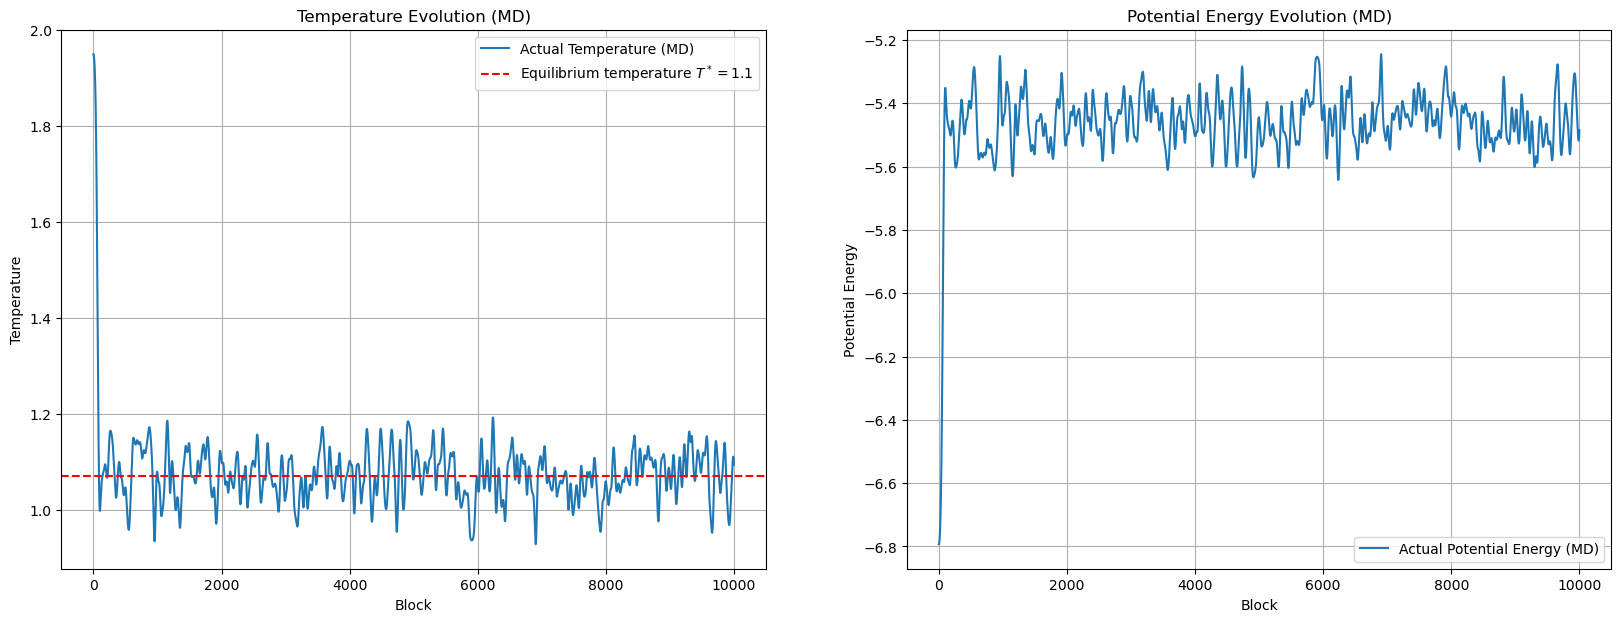

In [315]:
equilibrium_T = np.mean(temperature_MD_eq[-6000:])
print(f"Equilibrium temperature T* = {equilibrium_T:.1f}")

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

axs[0].plot(temperature_MD_eq, label="Actual Temperature (MD)")
axs[0].axhline(equilibrium_T, c='red', linestyle='--', label=f'Equilibrium temperature $T^* = ${equilibrium_T:.1f}')
axs[0].set_xlabel("Block")
axs[0].set_ylabel("Temperature")
axs[0].set_title("Temperature Evolution (MD)")
axs[0].legend()
axs[0].grid()

axs[1].plot(potential_energy_MD_eq, label="Actual Potential Energy (MD)")
axs[1].set_xlabel("Block")
axs[1].set_ylabel("Potential Energy")
axs[1].set_title("Potential Energy Evolution (MD)")
axs[1].legend()
axs[1].grid()

plt.show()

Start with equilibration for Montecarlo: I run the simulation for 500 blocks of 1 step each and plot. See that after 500 steps the system is well equilibrated. Restart from the configuration reached copying the output config.xyz into the input conf-1.xyz

### Run Molecular Dynamics (NVE)

In order to run the simulation on the equilibrated system I copied the `NSL_SIMULATOR/OUTPUT/CONFIG/config.xyz` into `NSL_SIMULATOR/INPUT/CONFIG/config.xyz` and `NSL_SIMULATOR/OUTPUT/CONFIG/conf-1.xyz` into `NSL_SIMULATOR/INPUT/CONFIG/conf-1.xyz`, and put `RESTART=1` in `input.dat`. This way the algorithm initializes velocities based on the second to last configuration and starts from the last one. I change the number of blocks to 500000 with 1 step per block. This time I only record potential energy so that the simulation runs a bit faster.

On the instantaneous values of potential energy per particle I calculated the autocorrelation function, which plot is showed below. To the left the plot is in linear scale, while to the right the $y-$axis is represented in logarithmic scale.

In [244]:
path_MD = "NSL_SIMULATOR/OUTPUT/BACKUP/EX7_2/MD/"
_, potential_energy_MD, _, _ = np.loadtxt(path_MD + "potential_energy_MD.dat", unpack=True)

In [245]:
tau = np.arange(0, 1000, 1)
autocorr_values = [autocorrelation(potential_energy_MD, t) for t in tau]

# Perform the exponential fit knowing it is going to fail
popt, pcov = curve_fit(exponential_decay, tau, autocorr_values)
tau_c = popt[0]

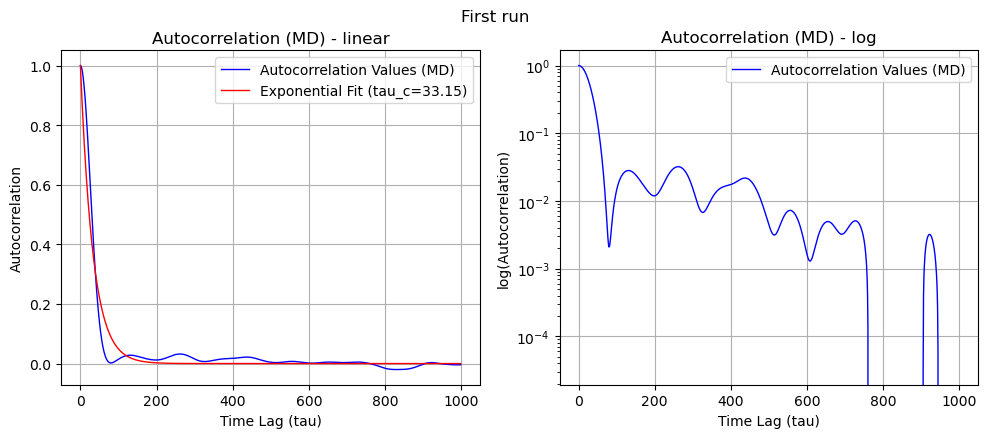

In [256]:
plt.figure(figsize=(10, 12))

plt.suptitle('First run')

plt.subplot(3, 2, 1)
plt.plot(tau, autocorr_values, color='blue', linewidth=1, label="Autocorrelation Values (MD)")
plt.plot(tau, exponential_decay(tau, tau_c), color='red', linewidth=1, label=f"Exponential Fit (tau_c={tau_c:.2f})")
plt.xlabel("Time Lag (tau)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation (MD) - linear")
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.plot(tau, autocorr_values, color='blue', linewidth=1, label="Autocorrelation Values (MD)")
#plt.plot(tau, exponential_decay(tau, tau_c), color='red', linewidth=1, label=f"Exponential Fit (tau_c={tau_c:.2f})")
plt.yscale('log')
plt.xlabel("Time Lag (tau)")
plt.ylabel("log(Autocorrelation)")
plt.title("Autocorrelation (MD) - log")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In these plots one can see that an exponential fit is not well suited to describe the autocorrelation in this case. This is partly due to the fact that the system is a very complex one, with 108 particles with a non trivial interactig potential. The most important fact though is that Molecular Dynamics algorithms are not made to explore the phase space with a random walk, but rather to visit successive configurations following the solutions of the motion equations. Therefore every point of the trajectory is theoretically correlated with all previous ones. One can only define the configurations uncorrelated from each other in an improper sense observing that the most time is passes, the harder it is to recover the previous configurations.

But for example one sees the trend of the autocorrelation decreasing, but then a peak after around 900 steps. In order to establish wether this is a memory comeback or just a coincidence, I run the simulation for another 500000 starting from the last reached configuration, to see if some form of periodicity shows. The plots below show the result of this second run

In [247]:
_, potential_energy_MD_2, _, _ = np.loadtxt(path_MD + "potential_energy_MD_2.dat", unpack=True)

In [248]:
tau = np.arange(0, 1000, 1)
autocorr_values = [autocorrelation(potential_energy_MD_2, t) for t in tau]

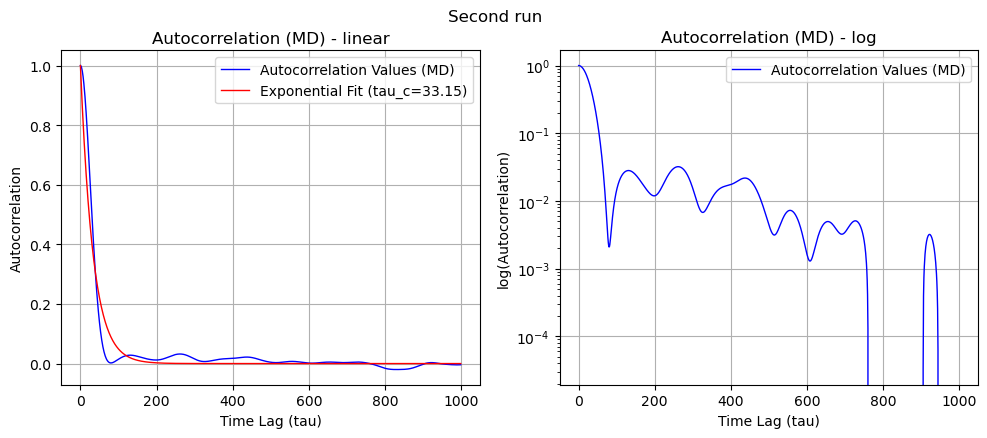

In [249]:
plt.figure(figsize=(10, 12))

plt.suptitle('Second run')

plt.subplot(3, 2, 1)
plt.plot(tau, autocorr_values, color='blue', linewidth=1, label="Autocorrelation Values (MD)")
plt.plot(tau, exponential_decay(tau, tau_c), color='red', linewidth=1, label=f"Exponential Fit (tau_c={tau_c:.2f})")
plt.xlabel("Time Lag (tau)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation (MD) - linear")
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.plot(tau, autocorr_values, color='blue', linewidth=1, label="Autocorrelation Values (MD)")
#plt.plot(tau, exponential_decay(tau, tau_c), color='red', linewidth=1, label=f"Exponential Fit (tau_c={tau_c:.2f})")
plt.yscale('log')
plt.xlabel("Time Lag (tau)")
plt.ylabel("log(Autocorrelation)")
plt.title("Autocorrelation (MD) - log")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

There can be not recognised a proper periodicity, but the peak arises in a position that is quite close to the previous one, so the hypotesis of a potential periodicity cannot be completely excluded.

However, for the sake of the exercise we can establish that after 1000 steps, the configurations can be considered (improperly) uncorrelated.

## Montecarlo (NVT)

### Equilibration (MC)
For the Montecarlo simulation I need to equilibrate the system starting from the FCC configuration as descripted above. I ran the simulation with the following parameters in `input.dat`, only recording the potential energy and acceptance (temperature is a fixed parameter of the system).

| Parameter | Value |
| :--- | :--- |
| **SIMULATION_TYPE** | `1` |
| **RESTART** | `0` |
| **TEMP** | `1.1` |
| **NPART** | `108` | 
| **RHO** | `0.8` |
| **R_CUT** | `2.5` |
| **DELTA** | `0.1` |
| **NBLOCKS** | `10000` |
| **NSTEPS** | `1` |

With this choiche of `DELTA` we can observe that acceptance fluctuates around $\sim 50\%$. In the plot below I show the instantaneous values of the potential energy and the progressive acceptance values. The acceptance values converge to around $\sim 50\%$.

From the plot of the potential energy one can see that after 10000 steps the system has equilibrated.

In [251]:
path_eq_MC = "NSL_SIMULATOR/OUTPUT/BACKUP/EQUILIBRATION/MONTECARLO/"

In [255]:
_, acceptance_MC_eq = np.loadtxt(path_eq_MC + "acceptance_MC_eq.dat", unpack=True)
_, potential_energy_MC_eq, _, _ = np.loadtxt(path_eq_MC + "potential_energy_MC_eq.dat", unpack=True)

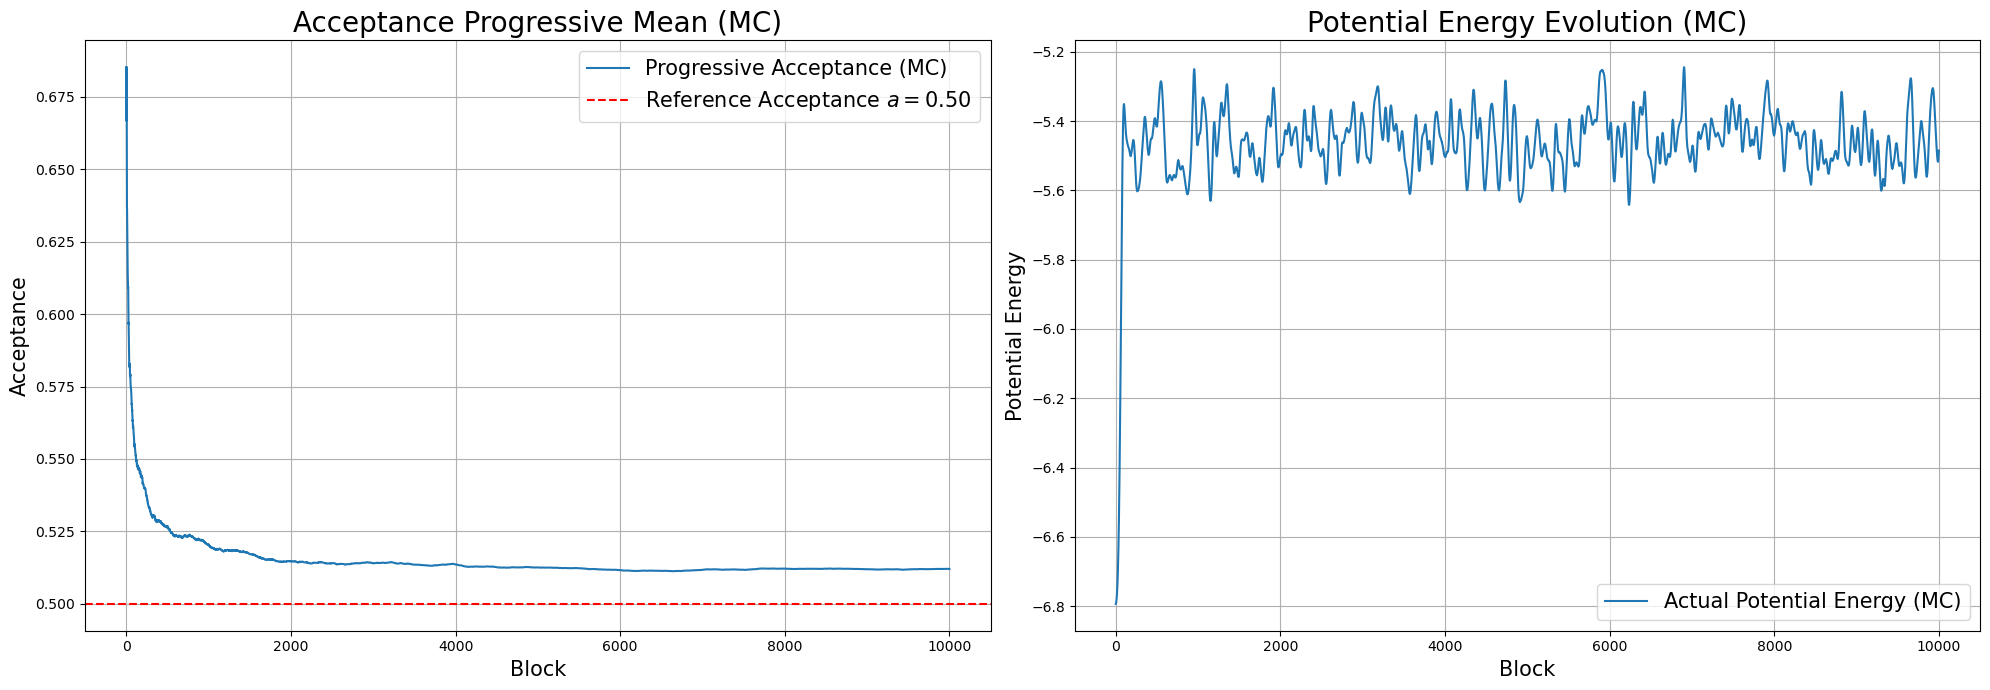

In [274]:
reference_a = 0.50

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

axs[0].plot(acceptance_MC_eq, label="Progressive Acceptance (MC)")
axs[0].axhline(reference_a, c='red', linestyle='--', label=f'Reference Acceptance $a = ${reference_a:.2f}')
axs[0].set_xlabel("Block", fontsize=15)
axs[0].set_ylabel("Acceptance", fontsize=15)
axs[0].set_title("Acceptance Progressive Mean (MC)", fontsize=20)
axs[0].legend(fontsize=15)
axs[0].grid()

axs[1].plot(potential_energy_MD_eq, label="Actual Potential Energy (MC)")
axs[1].set_xlabel("Block", fontsize=15)
axs[1].set_ylabel("Potential Energy", fontsize=15)
axs[1].set_title("Potential Energy Evolution (MC)", fontsize=20)
axs[1].legend(fontsize=15)
axs[1].grid()

plt.tight_layout()
plt.show()

### Run Montecarlo (NVT)

In order to collect the data on the instantaneous values of the potential energy per particle, I restarted the simulation from the last configuration contained in `OUTPUT/CONFIG/config.xyz` into `INPUT/CONFIG/config.xyz`. This time putting `RESTART=1` has no effect, since that is only needen when Verlet algorithm is involved.

The simulation runs for 500000 blocks of 1 step each and I only record the potential energy.

On this data I calculate the autocorrelation function as described for the Molecular Dynamics. The result is showed in the plot below. To the left the graph in linear scale and to the right with the vertical axis in logarithmic scale.

In [283]:
path_MC = "NSL_SIMULATOR/OUTPUT/BACKUP/EX7_2/MONTECARLO/"
_, potential_energy_MC, _, _ = np.loadtxt(path_MC + "potential_energy_MC.dat", unpack=True)

In [284]:
tau = np.arange(0, 500, 1)
autocorr_values = [autocorrelation(potential_energy_MC, t) for t in tau]

# Perform the exponential fit (knowing it won't fit)
popt, pcov = curve_fit(exponential_decay, tau, autocorr_values)
tau_c = popt[0]

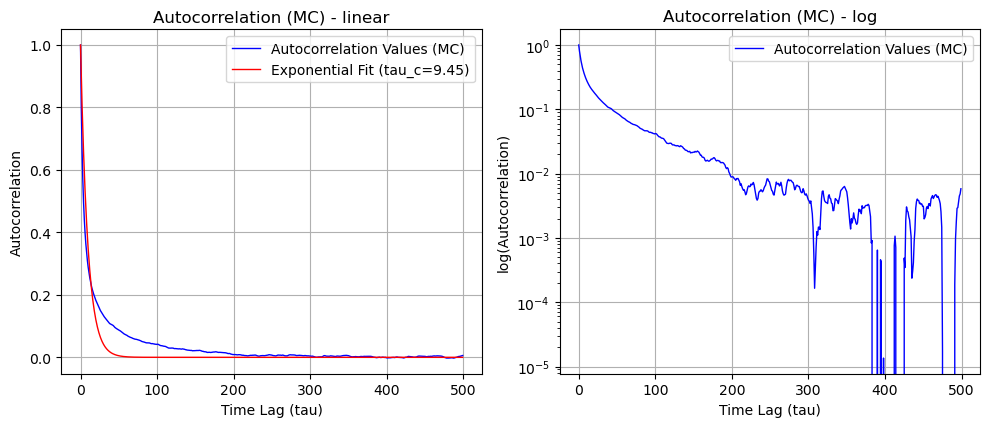

In [285]:
plt.figure(figsize=(10, 12))

plt.subplot(3, 2, 1)
plt.plot(tau, autocorr_values, color='blue', linewidth=1, label="Autocorrelation Values (MC)")
plt.plot(tau, exponential_decay(tau, tau_c), color='red', linewidth=1, label=f"Exponential Fit (tau_c={tau_c:.2f})")
plt.xlabel("Time Lag (tau)")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation (MC) - linear")
plt.legend()
plt.grid(True)

plt.subplot(3, 2, 2)
plt.plot(tau, autocorr_values, color='blue', linewidth=1, label="Autocorrelation Values (MC)")
#plt.plot(tau, exponential_decay(tau, tau_c), color='red', linewidth=1, label=f"Exponential Fit (tau_c={tau_c:.2f})")
plt.yscale('log')
plt.xlabel("Time Lag (tau)")
plt.ylabel("log(Autocorrelation)")
plt.title("Autocorrelation (MC) - log")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Also here the exponential fit does not work and this is due to the very complex nature of the system. Also Montecarlo is a Stochastic Process, that actually produces a proper autocorrelation function that shows proper fluctuations around zero and not a quite smooth curve like in Molecular Dynamics.

This time we can properly say that after $\sim500$ steps the system is correctly uncorrelated.

The autocorrelation study is needed to determine how long the blocks should be in order to collect independent block means and therefore the correct statistical uncertainty.

### Study of uncertainty

Now we want to plot the statistical uncertainty deriving from the data blocking technique, using increasingly larger blocks: to do so we take the previously collected data and apply the data blocking technique: we divide into blocks, calculate the mean in each block, calculate the mean of the means and the final statistical uncertainty using the means over all the blocks.

The statistical uncertainties, i.e. the standard deviation of the mean, is an estimation of the variance $\sigma^2$. The variance can be computed as
$$\sigma^2_A := \langle (A-\langle A\rangle)^2\rangle = \langle A^2 \rangle -\langle A\rangle^2 $$

In order to obtain those means, one should take the means deriving from each of the $N$ blocks and average over them. In particular
$$ \langle A^2 \rangle \simeq \frac{1}{N} \sum_{i=1}^N A^2_i \quad \quad \langle A\rangle^2 \simeq \left( \frac{1}{N} \sum_{i=1}^N A_i \right)^2 $$

The statistical uncertainty with $N$ blocks is computed as:
$$\frac{\sigma}{\sqrt{N-1}} \simeq \sqrt{\frac{1}{N-1} \left[ \frac{1}{N} \sum_{i=1}^N A^2_i - \left( \frac{1}{N} \sum_{i=1}^N A_i \right)^2 \right]} $$

What we observe both for Molecular Dynamics and Montecarlo is that the uncertainty with small blocks is very small, and increases with the length of the block: this is because taking small blocks means taking very correlated measurements and therefore the mean deriving from a block will be very close to the one deriving from the next one, therefore there is little difference and the uncertainty is very small. Increasing the length of the blocks helps having uncorrelated measurements, at the cost (in this case, where we have generated a fixed number of data) of having less statistics: what we observe is that the uncertainty reaches a plateau, but fluctuations get bigger and bigger due to the lack of statistics 

In [286]:
def data_blocking_error(data, L):
    # Number of full blocks
    N = len(data) // L
    
    if N <= 1:
        return 0.0 # Only one block no uncertainty
    
    # Truncate the data array to make it the length of a multiple of L
    data_truncated = data[:N*L]
    
    # Data reorganized in a matrix of N rows and L columns
    # Each row is a block
    blocks = data_truncated.reshape(N, L)
    
    # Block mean: sum along the row (the column index shifts)
    block_means = np.mean(blocks, axis=1)
    
    global_mean = np.mean(block_means)
    global_mean_squared = np.mean(block_means**2)
    
    # Statistical error
    error = np.sqrt((global_mean_squared - global_mean**2) / (N - 1))
    
    return error

In [320]:
L_values = np.arange(10, 5001, 10) 

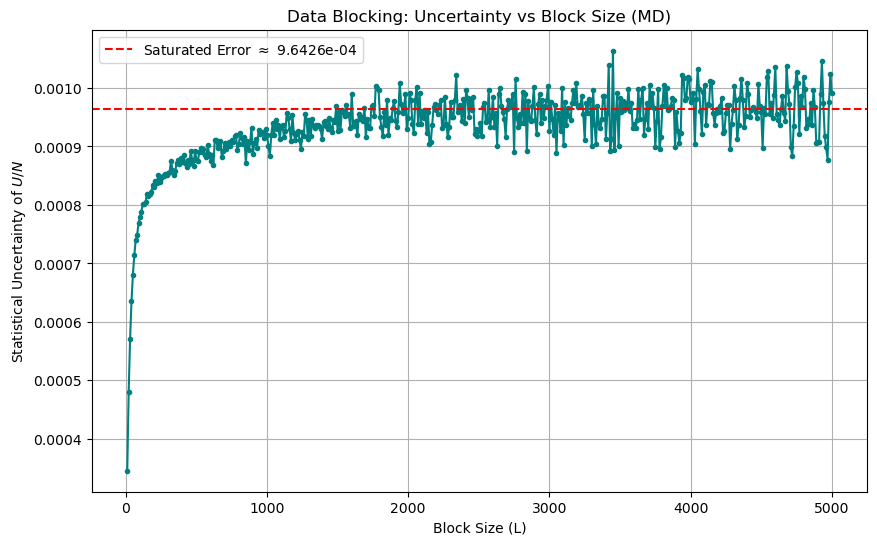

In [323]:
# ==========================================
# MOLECULAR DYNAMICS
# ==========================================

errors = [data_blocking_error(potential_energy_MD, L) for L in L_values]


plt.figure(figsize=(10, 6))
plt.plot(L_values, errors, marker='o', markersize=3, linestyle='-', color='teal')
plt.xlabel("Block Size (L)")
plt.ylabel("Statistical Uncertainty of $U/N$")
plt.title("Data Blocking: Uncertainty vs Block Size (MD)")
plt.grid(True)

saturated_error = np.mean(errors[-50:])
plt.axhline(saturated_error, color='red', linestyle='--', label=f'Saturated Error $\\approx$ {saturated_error:.4e}')

plt.legend()
plt.show()

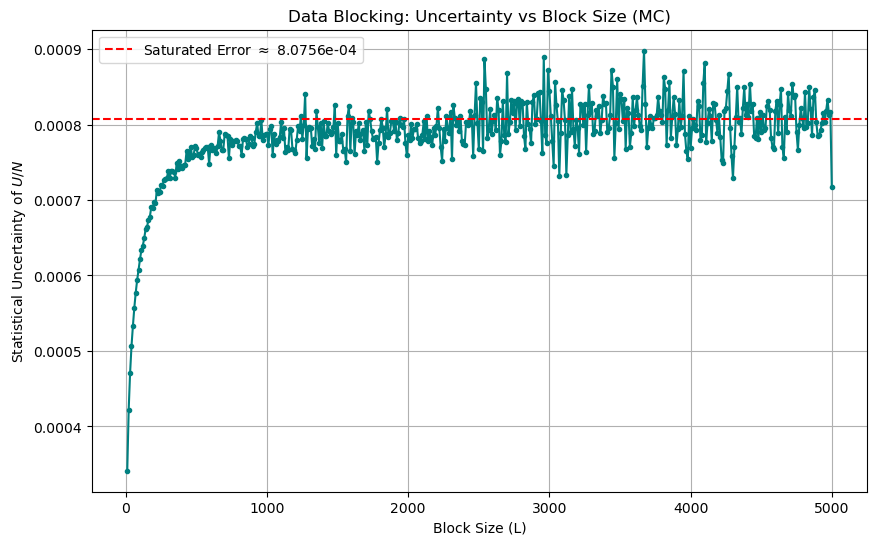

In [324]:
# ==========================================
# MONTECARLO
# ==========================================

errors = [data_blocking_error(potential_energy_MC, L) for L in L_values]

plt.figure(figsize=(10, 6))
plt.plot(L_values, errors, marker='o', markersize=3, linestyle='-', color='teal')
plt.xlabel("Block Size (L)")
plt.ylabel("Statistical Uncertainty of $U/N$")
plt.title("Data Blocking: Uncertainty vs Block Size (MC)")
plt.grid(True)

saturated_error = np.mean(errors[-50:])
plt.axhline(saturated_error, color='red', linestyle='--', label=f'Saturated Error $\\approx$ {saturated_error:.4e}')

plt.legend()
plt.show()

# Exercise 7.3)

## Radial distribution function $g(r)$

A monoatomic fluid can be characterized by certain distribution functions for the atomic positions. The simplest one is the radial distribution function $g(r)$ that represents the probability density of finding two atoms at a distance $r$ apart relarive to the probability expected for a completely random distribution, i.e. an ideal gas, at the same density.

In a system of $N$ particles, the radial distribution is the following
$$g(\vec{r}) = \frac{1}{\rho N}\left<\sum\sum_{i\neq j=1}^N \delta\left[\vec{r} - \left(\vec{r}_i -\vec{r}_j\right)\right]\right>$$
which is reported as a function of the modulus of the radius averaging over all angles
$$g(r) = \langle g(\vec{r}) \rangle_{\substack{r \in [r, r+dr] \\ \theta \in [0, \pi] \\ \phi \in [0, 2\pi]}} = \frac{1}{\rho N \Delta V(r)} \left\langle \sum_{i \neq j} \delta(|\vec{r}| - |\vec{r}_i - \vec{r}_j|) \right\rangle$$
where
$$\Delta V(r) = \frac{4\pi}{3} \left[ (r+dr)^3 - r^3 \right]$$
is the volume of the spherical shell between radius $r$ and $(r+dr)$, which is needed for normalization, since spherical shells at bigger radiuses include mode volume, and therefore more probability to find particles.

The implementation follows the construction of an histogram and for each radius bin every time the distance between two particles is in that bin, the count increases by two (there are two particles at distance $r$).

# Exercise 7.4

## Plots of potential energy, pressure and $g(r)$

Having studied the ideal length of blocks in order to obtain uncorrelated measurements and correct statistical uncertainty estimation, we want to finally calculate the interesting properties of the system. 

First I have to reequilibrate the system: so for both Molecular Dynamics and Montecarlo I run two simulation recording only temperature and potential energy for MD and only potential energy fot MC. Below are the two plots that show equilibration for 10000 steps.

In [345]:
path_MD4 = "NSL_SIMULATOR/OUTPUT/BACKUP/EX7_4/MD/"
path_MC4 = "NSL_SIMULATOR/OUTPUT/BACKUP/EX7_4/MONTECARLO/"

_, kinetic_energy_MD_eq4, _, _ = np.loadtxt(path_MD_eq4 + "kinetic_energy_MD_eq4.dat", unpack=True)
_, temperature_MD_eq4, _, _ = np.loadtxt(path_MD_eq4 + "temperature_MD_eq4.dat", unpack=True)
_, potential_energy_MD_eq4, _, _ = np.loadtxt(path_MD_eq4 + "potential_energy_MD_eq4.dat", unpack=True)

_, acceptance_MC_eq4 = np.loadtxt(path_MC_eq4 + "acceptance_MC_eq4.dat", unpack=True)
_, potential_energy_MC_eq4, _, _ = np.loadtxt(path_MC_eq4 + "potential_energy_MC_eq4.dat", unpack=True)

Equilibrium temperature T* = 1.1


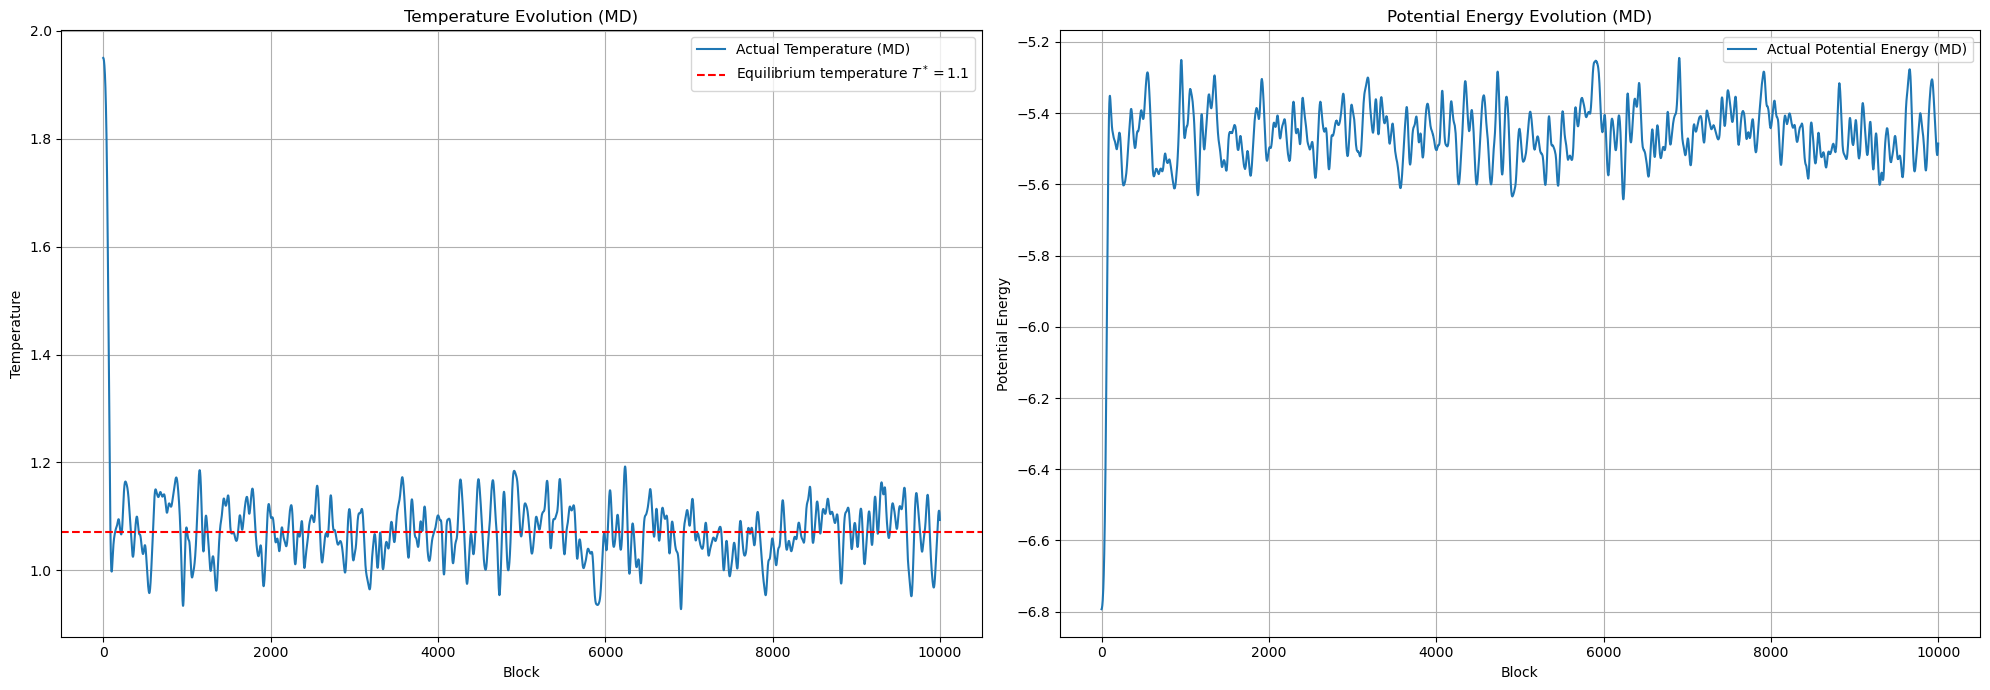

In [346]:
# ==========================================
# MOLECULAR DYNAMICS - EQUILIBRATION
# ==========================================

equilibrium_T = np.mean(temperature_MD_eq4[-6000:])
print(f"Equilibrium temperature T* = {equilibrium_T:.1f}")

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

axs[0].plot(temperature_MD_eq4, label="Actual Temperature (MD)")
axs[0].axhline(equilibrium_T, c='red', linestyle='--', label=f'Equilibrium temperature $T^* = ${equilibrium_T:.1f}')
axs[0].set_xlabel("Block")
axs[0].set_ylabel("Temperature")
axs[0].set_title("Temperature Evolution (MD)")
axs[0].legend()
axs[0].grid()

axs[1].plot(potential_energy_MD_eq4, label="Actual Potential Energy (MD)")
axs[1].set_xlabel("Block")
axs[1].set_ylabel("Potential Energy")
axs[1].set_title("Potential Energy Evolution (MD)")
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()

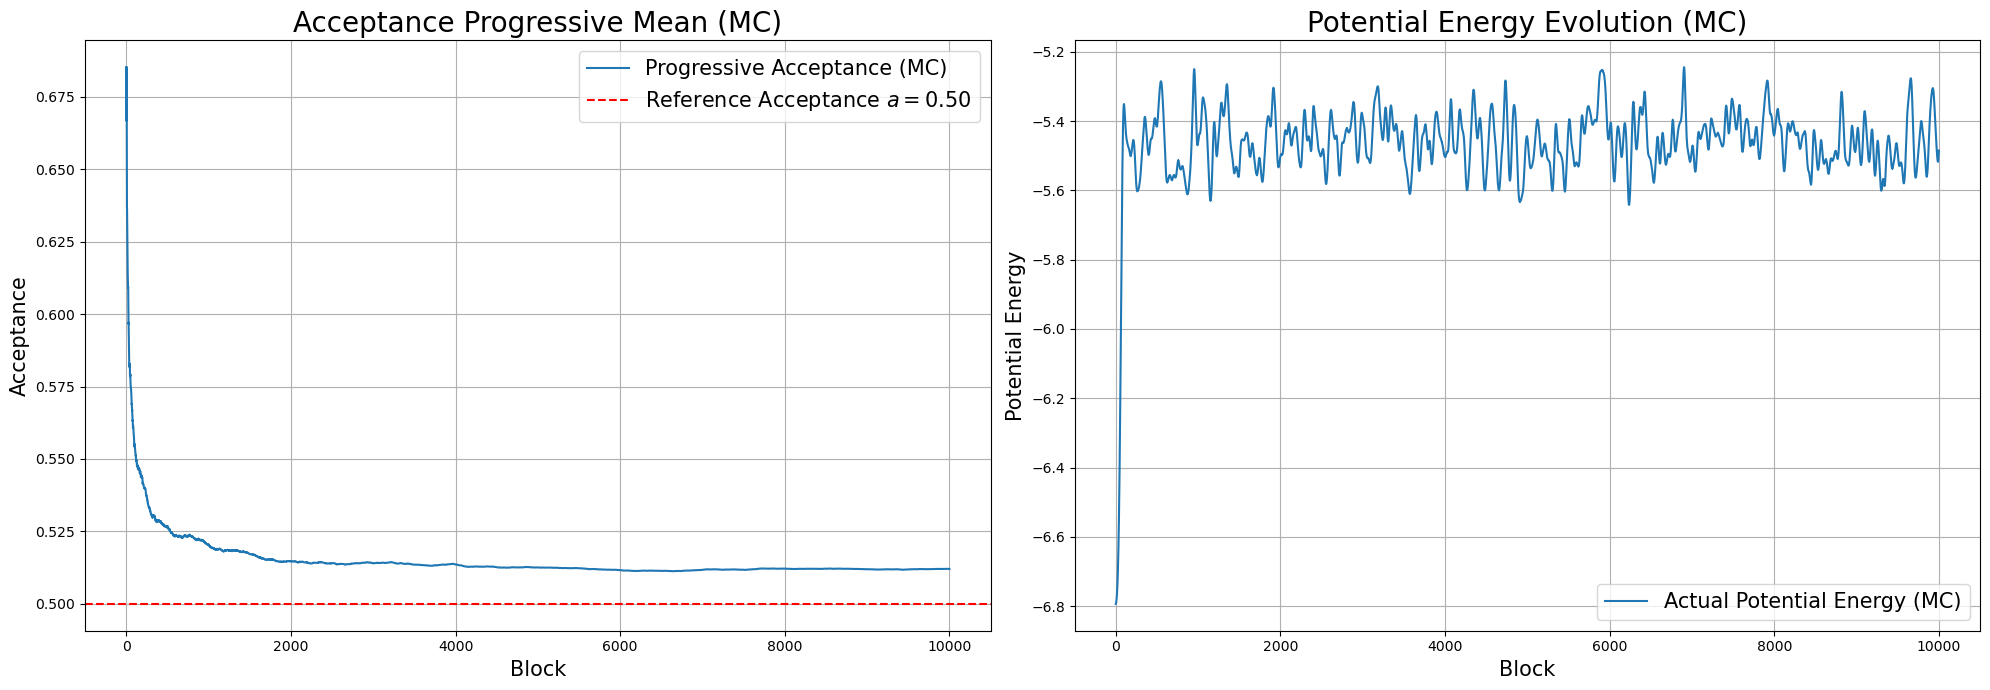

In [347]:
# ==========================================
# MONTECARLO - EQUILIBRATION
# ==========================================

reference_a = 0.50

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

axs[0].plot(acceptance_MC_eq4, label="Progressive Acceptance (MC)")
axs[0].axhline(reference_a, c='red', linestyle='--', label=f'Reference Acceptance $a = ${reference_a:.2f}')
axs[0].set_xlabel("Block", fontsize=15)
axs[0].set_ylabel("Acceptance", fontsize=15)
axs[0].set_title("Acceptance Progressive Mean (MC)", fontsize=20)
axs[0].legend(fontsize=15)
axs[0].grid()

axs[1].plot(potential_energy_MD_eq4, label="Actual Potential Energy (MC)")
axs[1].set_xlabel("Block", fontsize=15)
axs[1].set_ylabel("Potential Energy", fontsize=15)
axs[1].set_title("Potential Energy Evolution (MC)", fontsize=20)
axs[1].legend(fontsize=15)
axs[1].grid()

plt.tight_layout()
plt.show()

In the following plots I show first the progressive average of potential energy and pressure obrained through Molecular Dynamics and Montecarlo respectively. In the plot after, I show the radial distribution function $g(r)$ final estimation (bin countings obtained in the last block with uncertainty) obtained with Molecular Dynamics and Montecarlo superimposed. To the right I show the difference between the two curves, to amplify the uncertainties.

What is shown here is that in the thermodynamic limit the two ensembles, NVE simulated with Molecular Dynamics and NVT simulated with Montecarlo, are equivalent, i.e. they give rise to the same thermodynamical properties. To be sure that the means I am considering are independent I run the simulation with 40 blocks of 20000 steps each.

In [355]:
blk_md, epot_md, err_epot_md = np.loadtxt(path_MD4 + "potential_energy_MD4.dat", usecols=(0, 2, 3), unpack=True)
blk_mc, epot_mc, err_epot_mc = np.loadtxt(path_MC4 + "potential_energy_MC4.dat", usecols=(0, 2, 3), unpack=True)

blk_mc, pres_mc, err_pres_mc = np.loadtxt(path_MC4 + "pressure_MC4.dat", usecols=(0, 2, 3), unpack=True)
blk_md, pres_md, err_pres_md = np.loadtxt(path_MD4 + "pressure_MD4.dat", usecols=(0, 2, 3), unpack=True)

r, gofr_mc, err_gofr_mc = np.loadtxt(path_mc + "gofr_MC4.dat", usecols=(0, 1, 2), unpack=True)
r, gofr_md, err_gofr_md = np.loadtxt(path_md + "gofr_MD4.dat", usecols=(0, 1, 2), unpack=True)

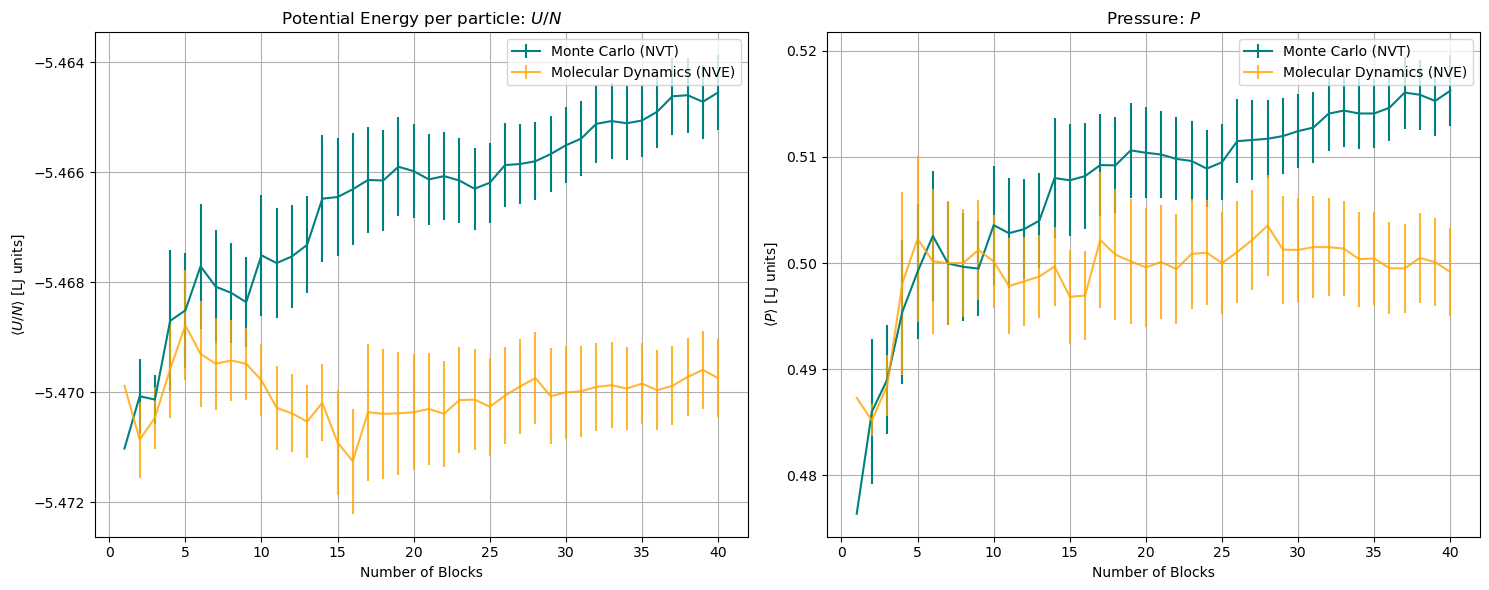

In [349]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Potential Energy
ax1.errorbar(blk_mc, epot_mc, yerr=err_epot_mc, label="Monte Carlo (NVT)", color='teal')
ax1.errorbar(blk_md, epot_md, yerr=err_epot_md, label="Molecular Dynamics (NVE)", color='orange', alpha=0.8)
ax1.set_title("Potential Energy per particle: $U/N$")
ax1.set_xlabel("Number of Blocks")
ax1.set_ylabel("$\\langle U/N \\rangle$ [LJ units]")
ax1.grid(True)
ax1.legend()

# Pressure
ax2.errorbar(blk_mc, pres_mc, yerr=err_pres_mc, label="Monte Carlo (NVT)", color='teal')
ax2.errorbar(blk_md, pres_md, yerr=err_pres_md, label="Molecular Dynamics (NVE)", color='orange', alpha=0.8)
ax2.set_title("Pressure: $P$")
ax2.set_xlabel("Number of Blocks")
ax2.set_ylabel("$\\langle P \\rangle$ [LJ units]")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

# Divergent behaviour above

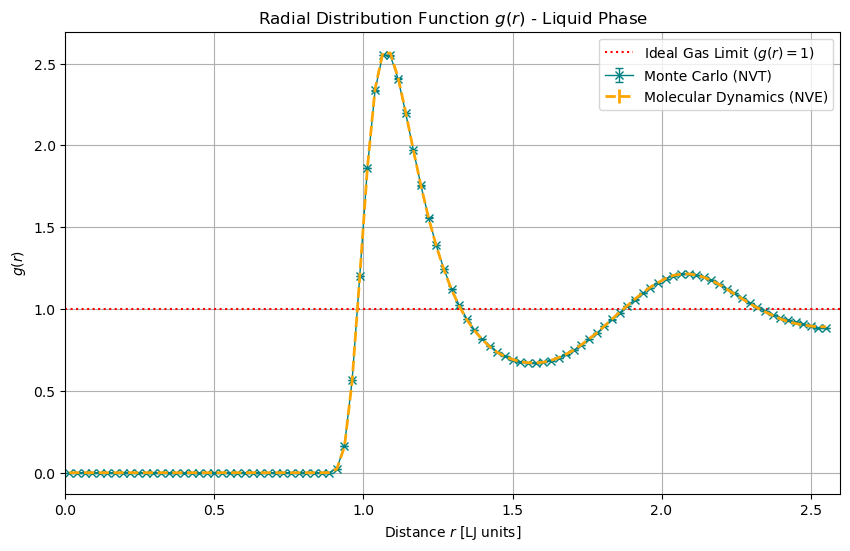

In [356]:
plt.figure(figsize=(10, 6))

# Radial distribution function g(r)
plt.errorbar(r, gofr_mc, yerr=err_gofr_mc, fmt='-x', capsize=3, color='teal', linewidth=1, label="Monte Carlo (NVT)")
plt.errorbar(r, gofr_md, yerr=err_gofr_md, label="Molecular Dynamics (NVE)", color='orange', linewidth=2, linestyle='--')

plt.axhline(1.0, color='red', linestyle=':', label="Ideal Gas Limit ($g(r)=1$)")

plt.title("Radial Distribution Function $g(r)$ - Liquid Phase")
plt.xlabel("Distance $r$ [LJ units]")
plt.ylabel("$g(r)$")
plt.xlim(0, 2.6) # Limite fisso al raggio di cut-off impostato
plt.grid(True)
plt.legend()

plt.show()

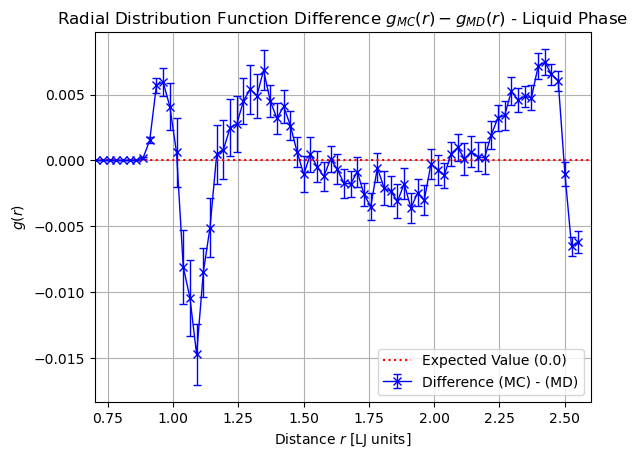

In [360]:
# Absolute difference
diff_err = np.sqrt(err_gofr_mc**2 + err_gofr_md**2)
plt.errorbar(r, gofr_mc - gofr_md, yerr=diff_err, fmt='-x', capsize=3, color='blue', linewidth=1, label="Difference (MC) - (MD)")

plt.axhline(0.0, color='red', linestyle=':', label="Expected Value (0.0)")

plt.title("Radial Distribution Function Difference $g_{MC}(r) - g_{MD}(r)$ - Liquid Phase")
plt.xlabel("Distance $r$ [LJ units]")
plt.ylabel("$g(r)$")
plt.xlim(0.7, 2.6) # Limite fisso al raggio di cut-off impostato
plt.grid(True)
plt.legend()

plt.show()